# Silica Concentrate — Soft Sensor (estimación en el instante t)

**Objetivo:** estimar `% Silica Concentrate` en el instante *t* a partir de los sensores
disponibles en ese mismo instante, para reducir la dependencia del análisis de laboratorio.

**Esto NO es forecasting.** No se predice el futuro: se sustituye una medida cara por una
estimación barata usando información simultánea. El forecasting está en el notebook
`02_forecasting_silica.ipynb`.

**Fuente:** https://www.kaggle.com/datasets/edumagalhaes/quality-prediction-in-a-mining-process

---
### Cambios respecto al notebook original
| Problema | Corrección |
|---|---|
| `train_test_split` aleatorio sobre serie temporal | Split **cronológico** por bloques. Barajar filas separadas 20 s filtra el test dentro del train. |
| `construir_features` definida dos veces | Una sola definición, antes de usarse. |
| `mean_squared_error` etiquetado como RMSE | `root_mean_squared_error` explícito. |
| `error` indefinido en la comparación naive | Baselines calculados en un único bloque. |
| `best_iteration` sin early stopping | `early_stopping_rounds` configurado en el constructor. |
| Detección de huecos sobre datos sin ordenar | Ordenación previa, un único DataFrame. |

## 1. Configuración

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")

# --- Parámetros del proyecto -------------------------------------------------
DATA_PATH        = Path("../Datasets/MiningProcess_Flotation_Plant_Database.csv")
TIMESTAMP_COL    = "date"
TARGET           = "% Silica Concentrate"

SAMPLING_SECONDS = 20            # cadencia nominal del registro
GAP_LIMIT        = pd.Timedelta(days=3)   # a partir de aquí, se corta el bloque
MIN_BLOCK_ROWS   = 15            # bloques menores no soportan lags/rolling
FROZEN_MIN_RUN   = 12_960        # 3 días de muestras congeladas -> sensor muerto
TEST_FRACTION    = 0.2           # último 20 % cronológico
RANDOM_STATE     = 42

## 2. Carga y tipado

El CSV usa coma decimal. `errors="coerce"` convierte cualquier texto corrupto en `NaN` para que aparezca en el chequeo de nulos en vez de fallar en silencio.

In [2]:
data = pd.read_csv(DATA_PATH)
data[TIMESTAMP_COL] = pd.to_datetime(data[TIMESTAMP_COL])

for col in data.select_dtypes(include=["object"]).columns:
    data[col] = pd.to_numeric(
        data[col].astype(str).str.replace(",", "."), errors="coerce"
    )

data = data.sort_values(TIMESTAMP_COL).reset_index(drop=True)

print(f"Filas: {len(data):,}   Columnas: {data.shape[1]}")
print(f"Rango temporal: {data[TIMESTAMP_COL].min()} -> {data[TIMESTAMP_COL].max()}")
print(f"Nulos tras conversión: {int(data.isna().sum().sum())}")
data.head()

Filas: 737,453   Columnas: 24
Rango temporal: 2017-03-10 01:00:00 -> 2017-09-09 23:00:00
Nulos tras conversión: 0


,date,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,Flotation Column 03 Air Flow,Flotation Column 04 Air Flow,Flotation Column 05 Air Flow,Flotation Column 06 Air Flow,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
0,2017-03-10 01:00:00,55.2,16.98,3019.53,557.434,395.713,10.0664,1.74000,249.214,253.235,250.576,295.096,306.4,250.225,250.884,457.396,432.962,424.954,443.558,502.255,446.370,523.344,66.91,1.31
1,2017-03-10 01:00:00,55.2,16.98,3185.55,586.182,404.648,10.1139,1.73614,250.488,250.488,249.214,295.096,306.4,250.137,248.950,450.139,510.332,461.638,422.888,451.528,510.098,513.904,66.91,1.31
2,2017-03-10 01:00:00,55.2,16.98,3182.03,595.947,407.168,10.1135,1.73545,250.620,252.334,249.390,295.096,306.4,256.465,251.499,440.530,518.600,465.414,405.704,433.686,513.794,512.252,66.91,1.31
3,2017-03-10 01:00:00,55.2,16.98,3180.86,600.464,402.598,10.1130,1.73476,250.576,250.620,249.258,295.096,306.4,250.137,250.269,443.833,510.446,456.246,415.706,428.618,481.874,468.224,66.91,1.31
4,2017-03-10 01:00:00,55.2,16.98,1272.66,594.971,393.516,10.1125,1.73407,250.488,249.302,249.302,295.096,306.4,247.983,248.511,453.242,502.968,451.604,441.878,427.296,433.372,412.824,66.91,1.31


In [3]:
data.info()
data.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 737453 entries, 0 to 737452
Data columns (total 24 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   date                          737453 non-null  datetime64[ns]
 1   % Iron Feed                   737453 non-null  float64       
 2   % Silica Feed                 737453 non-null  float64       
 3   Starch Flow                   737453 non-null  float64       
 4   Amina Flow                    737453 non-null  float64       
 5   Ore Pulp Flow                 737453 non-null  float64       
 6   Ore Pulp pH                   737453 non-null  float64       
 7   Ore Pulp Density              737453 non-null  float64       
 8   Flotation Column 01 Air Flow  737453 non-null  float64       
 9   Flotation Column 02 Air Flow  737453 non-null  float64       
 10  Flotation Column 03 Air Flow  737453 non-null  float64       
 11  Flotation Col

,count,mean,min,25%,50%,75%,max,std
date,737453,2017-06-16 03:27:22.656549376,2017-03-10 01:00:00,2017-05-04 23:00:00,2017-06-16 15:00:00,2017-07-29 07:00:00,2017-09-09 23:00:00,NaN
% Iron Feed,737453.0,56.294739,42.74,52.67,56.08,59.72,65.78,5.157744
% Silica Feed,737453.0,14.651716,1.31,8.94,13.85,19.6,33.4,6.807439
Starch Flow,737453.0,2869.140569,0.002026,2076.32,3018.43,3727.73,6300.23,1215.203734
Amina Flow,737453.0,488.144697,241.669,431.796,504.393,553.257,739.538,91.230534
Ore Pulp Flow,737453.0,397.578372,376.249,394.264,399.249,402.968,418.641,9.699785
Ore Pulp pH,737453.0,9.767639,8.75334,9.52736,9.7981,10.038,10.8081,0.387007
Ore Pulp Density,737453.0,1.68038,1.51982,1.64731,1.6976,1.72833,1.85325,0.069249
Flotation Column 01 Air Flow,737453.0,280.151856,175.51,250.281,299.344,300.149,373.871,29.621288
Flotation Column 02 Air Flow,737453.0,277.159965,175.156,250.457,296.223,300.69,375.992,30.149357


## 3. Duplicados de timestamp

El dataset original registra la calidad de laboratorio cada hora pero replica la misma
fila cada 20 s. Conviene saber cuántas muestras comparten el mismo instante antes de
interpretar cualquier métrica: el target apenas varía dentro de cada hora.

In [4]:
dups = data[TIMESTAMP_COL].duplicated().sum()
por_timestamp = data.groupby(TIMESTAMP_COL).size()

print(f"Timestamps duplicados: {dups:,}")
print(f"Muestras por timestamp — mediana: {por_timestamp.median():.0f}, "
      f"máx: {por_timestamp.max():.0f}")
print(f"Valores únicos del target dentro de un mismo timestamp (media): "
      f"{data.groupby(TIMESTAMP_COL)[TARGET].nunique().mean():.2f}")

Timestamps duplicados: 733,356
Muestras por timestamp — mediana: 180, máx: 180
Valores únicos del target dentro de un mismo timestamp (media): 14.54


## 4. Exploración

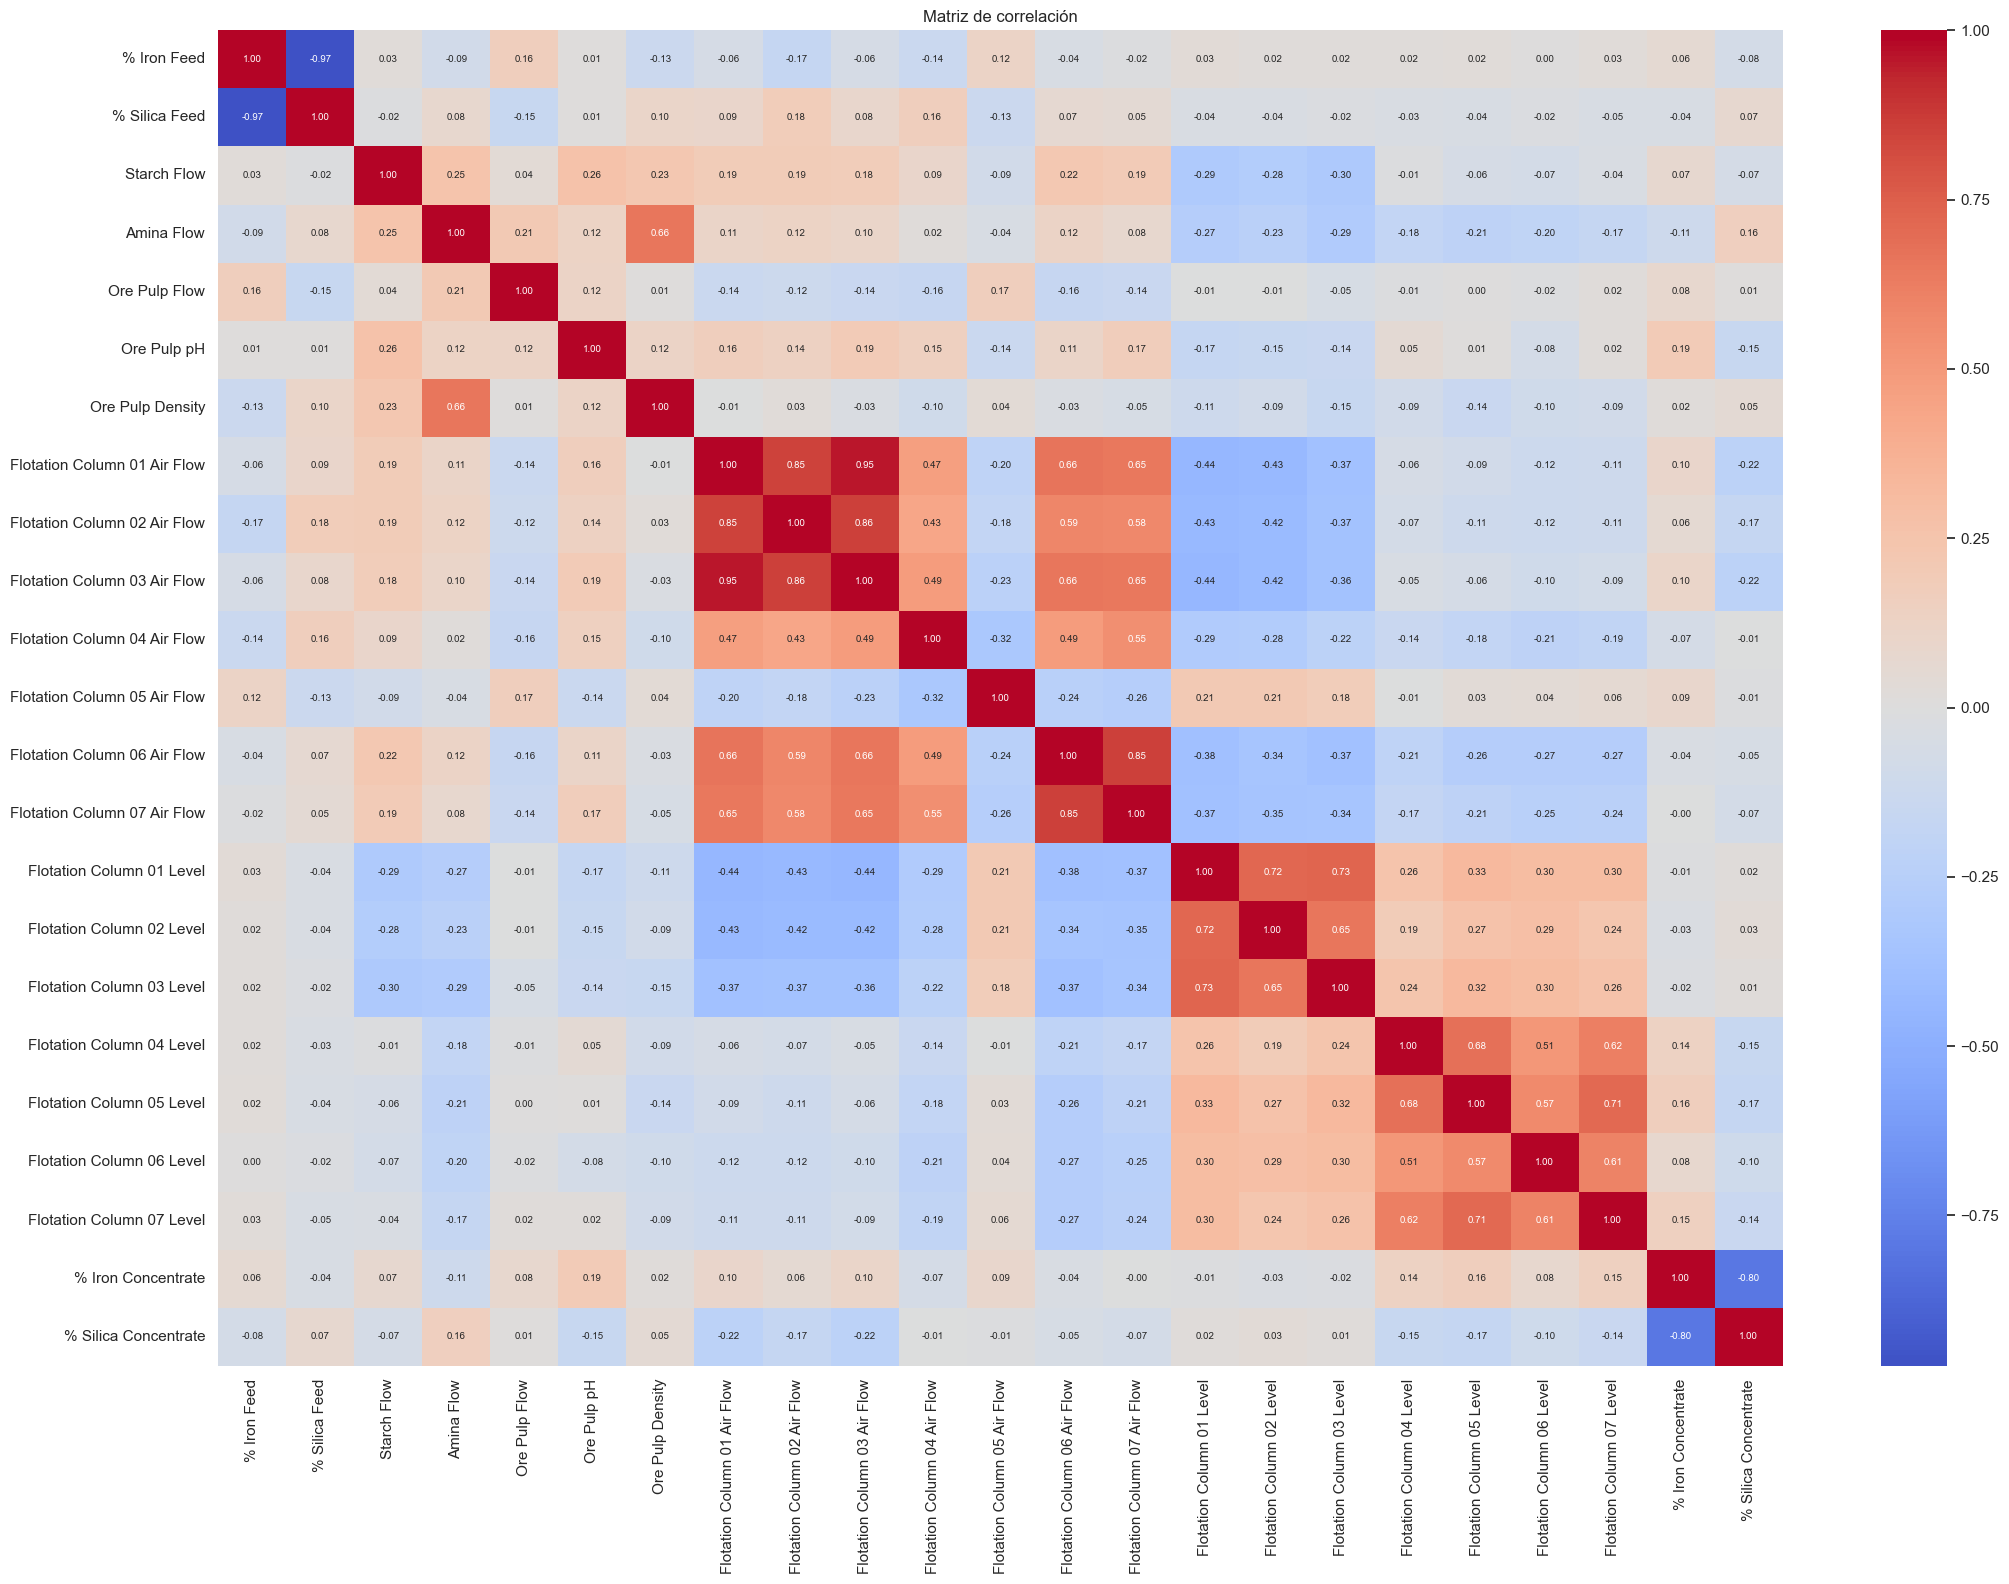

In [5]:
plt.figure(figsize=(22, 16))
sns.heatmap(data.drop(columns=[TIMESTAMP_COL]).corr(), annot=True, fmt=".2f",
            cmap="coolwarm", center=0, annot_kws={"size": 7})
plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

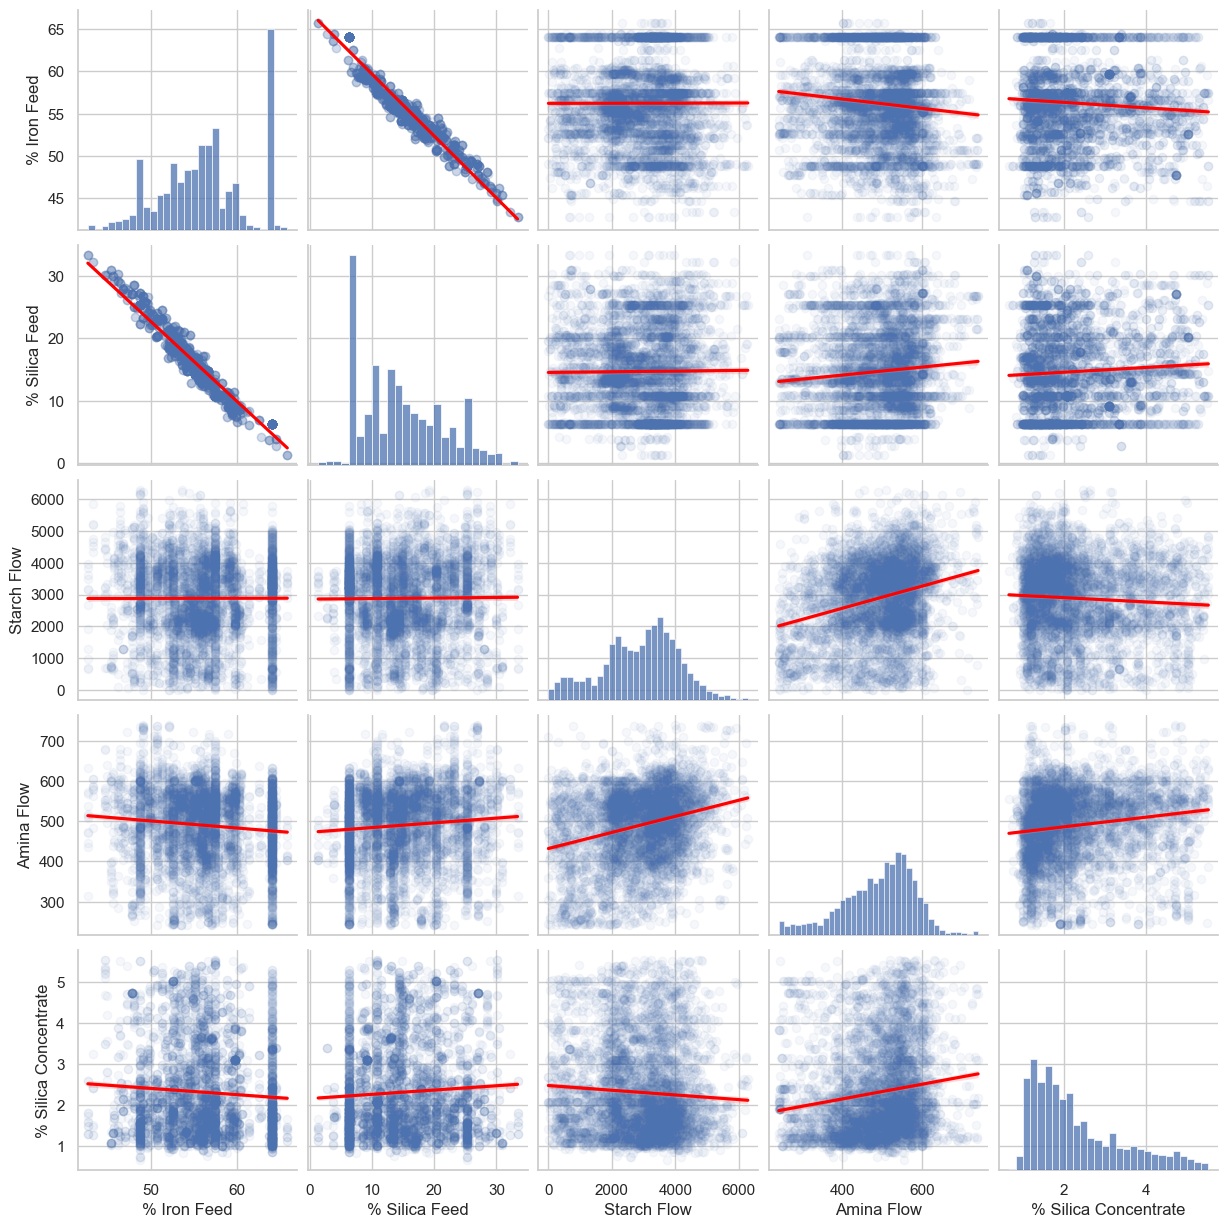

In [6]:
sns.pairplot(
    data.sample(5_000, random_state=RANDOM_STATE),
    vars=["% Iron Feed", "% Silica Feed", "Starch Flow", "Amina Flow", TARGET],
    kind="reg",
    plot_kws={"scatter_kws": {"alpha": 0.05}, "line_kws": {"color": "red"}},
)
plt.show()

Correlación positiva débil entre `% Silica Feed` y el target (esperable: más sílice
entrando, más sílice saliendo). Negativa débil con `% Iron Feed`, también esperable.

**Débil es la palabra clave.** Ninguna variable de alimentación explica el target por sí
sola; si el modelo acaba con un R² alto apoyándose en estas, sospecha de fuga.

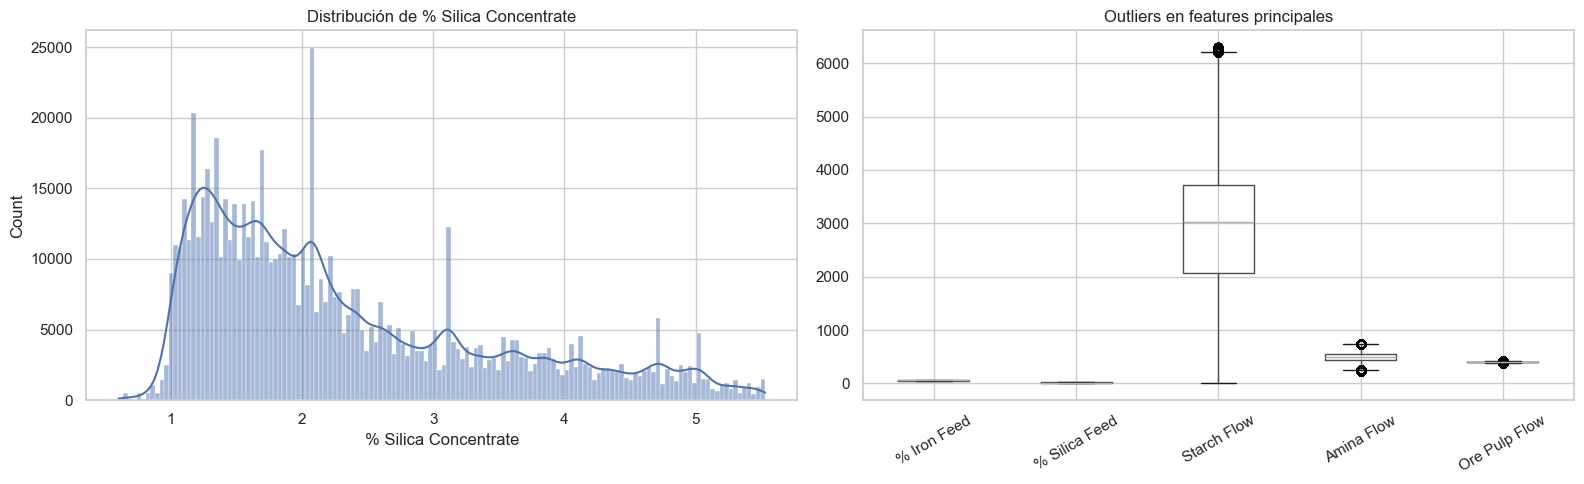

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(data[TARGET], kde=True, ax=axes[0])
axes[0].set_title(f"Distribución de {TARGET}")

data.boxplot(column=["% Iron Feed", "% Silica Feed", "Starch Flow",
                     "Amina Flow", "Ore Pulp Flow"], ax=axes[1])
axes[1].set_title("Outliers en features principales")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

Target sesgado a la derecha, pico en 1–2 %, rango 0.5–5 %. Los picos secundarios apuntan
a distintos regímenes de operación. `Starch Flow` y `Amina Flow` concentran los outliers
en la cola alta.

## 5. Selección de variables

Se descartan columnas redundantes (columnas de flotación altamente correlacionadas entre
sí) y `% Iron Concentrate`.

`% Iron Concentrate` es la decisión más importante de esta celda: en flotación,
hierro y sílice del concentrado son casi complementarios. Dejarla dentro es dar al modelo
una copia enmascarada de la respuesta, y explica buena parte del R² inflado de los
notebooks públicos sobre este dataset.

In [40]:
DROP_COLS = [
    "% Iron Feed",
    # "Ore Pulp pH",
    # "Flotation Column 02 Air Flow",
    # "Flotation Column 03 Air Flow",
    "Flotation Column 04 Air Flow",
    "Flotation Column 05 Air Flow",
    "Flotation Column 06 Air Flow",
    "Flotation Column 07 Air Flow",
    "Flotation Column 01 Level",
    "Flotation Column 02 Level",
    "Flotation Column 03 Level",
    "Flotation Column 05 Level",
    "Flotation Column 06 Level",
    "Flotation Column 07 Level",
    "Ore Pulp Flow",
    "% Iron Concentrate",   # complementario del target -> fuga
]

no_encontradas = set(DROP_COLS) - set(data.columns)
if no_encontradas:
    print(f"Aviso — no existen en el DataFrame: {sorted(no_encontradas)}")

df = data.drop(columns=[c for c in DROP_COLS if c in data.columns])
print(f"Shape tras selección: {df.shape}")
print(list(df.columns))

Shape tras selección: (737453, 11)
['date', '% Silica Feed', 'Starch Flow', 'Amina Flow', 'Ore Pulp pH', 'Ore Pulp Density', 'Flotation Column 01 Air Flow', 'Flotation Column 02 Air Flow', 'Flotation Column 03 Air Flow', 'Flotation Column 04 Level', '% Silica Concentrate']


## 6. Integridad temporal

Dos patologías distintas rompen los lags y las medias móviles:

1. **Huecos** — la planta paró y faltan horas o días.
2. **Sensores congelados** — el registro continúa pero el valor no cambia; el sensor está muerto pero el CSV no lo dice.

Ambas se tratan igual: cortar la serie en bloques continuos y no calcular ninguna feature temporal a través de un corte.

In [41]:
def detectar_huecos(df, col_tiempo=TIMESTAMP_COL, limite=GAP_LIMIT):
    """Devuelve los saltos temporales mayores que `limite`.

    Requiere el DataFrame ya ordenado cronológicamente.
    """
    delta = df[col_tiempo].diff()
    huecos = df.loc[delta > limite, [col_tiempo]].copy()
    huecos["fin_anterior"] = df[col_tiempo].shift(1).loc[huecos.index]
    huecos["duracion"] = delta.loc[huecos.index]
    return huecos.rename(columns={col_tiempo: "reanudacion"})


huecos = detectar_huecos(df)
print(f"Paradas de más de {GAP_LIMIT.days} días: {len(huecos)}\n")
huecos

Paradas de más de 3 días: 1



,reanudacion,fin_anterior,duracion
26814,2017-03-29 12:00:00,2017-03-16 05:00:00,13 days 07:00:00


In [42]:
def detectar_congelados(df, columnas, min_run=FROZEN_MIN_RUN,
                        col_tiempo=TIMESTAMP_COL):
    """Detecta tramos donde una variable no cambia durante `min_run` muestras."""
    rangos = []
    for var in columnas:
        sin_cambio = df[var].diff().eq(0)
        grupo = (sin_cambio != sin_cambio.shift()).cumsum()
        runs = (df.assign(_g=grupo, _f=sin_cambio)
                  .groupby("_g")
                  .agg(inicio=(col_tiempo, "first"),
                       fin=(col_tiempo, "last"),
                       n=(col_tiempo, "size"),
                       congelado=("_f", "first"),
                       valor=(var, "first")))
        sospechosos = runs[(runs["congelado"]) & (runs["n"] >= min_run)]
        for _, r in sospechosos.iterrows():
            print(f"{var}: congelado en {r['valor']:.3f} — "
                  f"{r['inicio']} -> {r['fin']} ({int(r['n']):,} muestras)")
            rangos.append((r["inicio"], r["fin"]))
    return rangos


VARS_VIGILADAS = ["% Silica Feed"]
rangos_muertos = detectar_congelados(df, VARS_VIGILADAS)
print(f"\nTramos inválidos: {len(rangos_muertos)}")

% Silica Feed: congelado en 20.240 — 2017-05-09 16:00:00 -> 2017-05-13 00:00:00 (14,579 muestras)
% Silica Feed: congelado en 6.260 — 2017-05-13 01:00:00 -> 2017-06-15 00:00:00 (142,559 muestras)
% Silica Feed: congelado en 10.800 — 2017-07-24 01:00:00 -> 2017-08-03 15:00:00 (45,899 muestras)
% Silica Feed: congelado en 25.310 — 2017-08-07 01:00:00 -> 2017-08-15 00:00:00 (34,559 muestras)

Tramos inválidos: 4


In [43]:
def partir_en_bloques(df, rangos_invalidos, col_tiempo=TIMESTAMP_COL,
                      limite_hueco=GAP_LIMIT, min_filas=MIN_BLOCK_ROWS):
    """Corta el DataFrame en bloques continuos y utilizables.

    Corta tanto en los huecos temporales como en los tramos marcados como
    inválidos, y descarta los bloques demasiado cortos para features con
    ventana.
    """
    valida = pd.Series(True, index=df.index)
    for inicio, fin in rangos_invalidos:
        valida &= ~((df[col_tiempo] >= inicio) & (df[col_tiempo] <= fin))

    hueco = df[col_tiempo].diff() > limite_hueco
    corte = (~valida | hueco).cumsum()

    bloques = [g.reset_index(drop=True)
               for _, g in df[valida].groupby(corte[valida])
               if len(g) >= min_filas]
    return bloques


bloques = partir_en_bloques(df, rangos_muertos)

print(f"Bloques válidos: {len(bloques)}")
for i, b in enumerate(bloques):
    print(f"  [{i}] {len(b):>7,} filas | "
          f"{b[TIMESTAMP_COL].min()} -> {b[TIMESTAMP_COL].max()}")
print(f"\nFilas conservadas: {sum(map(len, bloques)):,} de {len(df):,} "
      f"({sum(map(len, bloques)) / len(df):.1%})")

Bloques válidos: 5
  [0]  26,814 filas | 2017-03-10 01:00:00 -> 2017-03-16 05:00:00
  [1] 177,839 filas | 2017-03-29 12:00:00 -> 2017-05-09 15:00:00
  [2] 168,480 filas | 2017-06-15 01:00:00 -> 2017-07-24 00:00:00
  [3]  14,580 filas | 2017-08-03 16:00:00 -> 2017-08-07 00:00:00
  [4] 112,140 filas | 2017-08-15 01:00:00 -> 2017-09-09 23:00:00

Filas conservadas: 499,853 de 737,453 (67.8%)


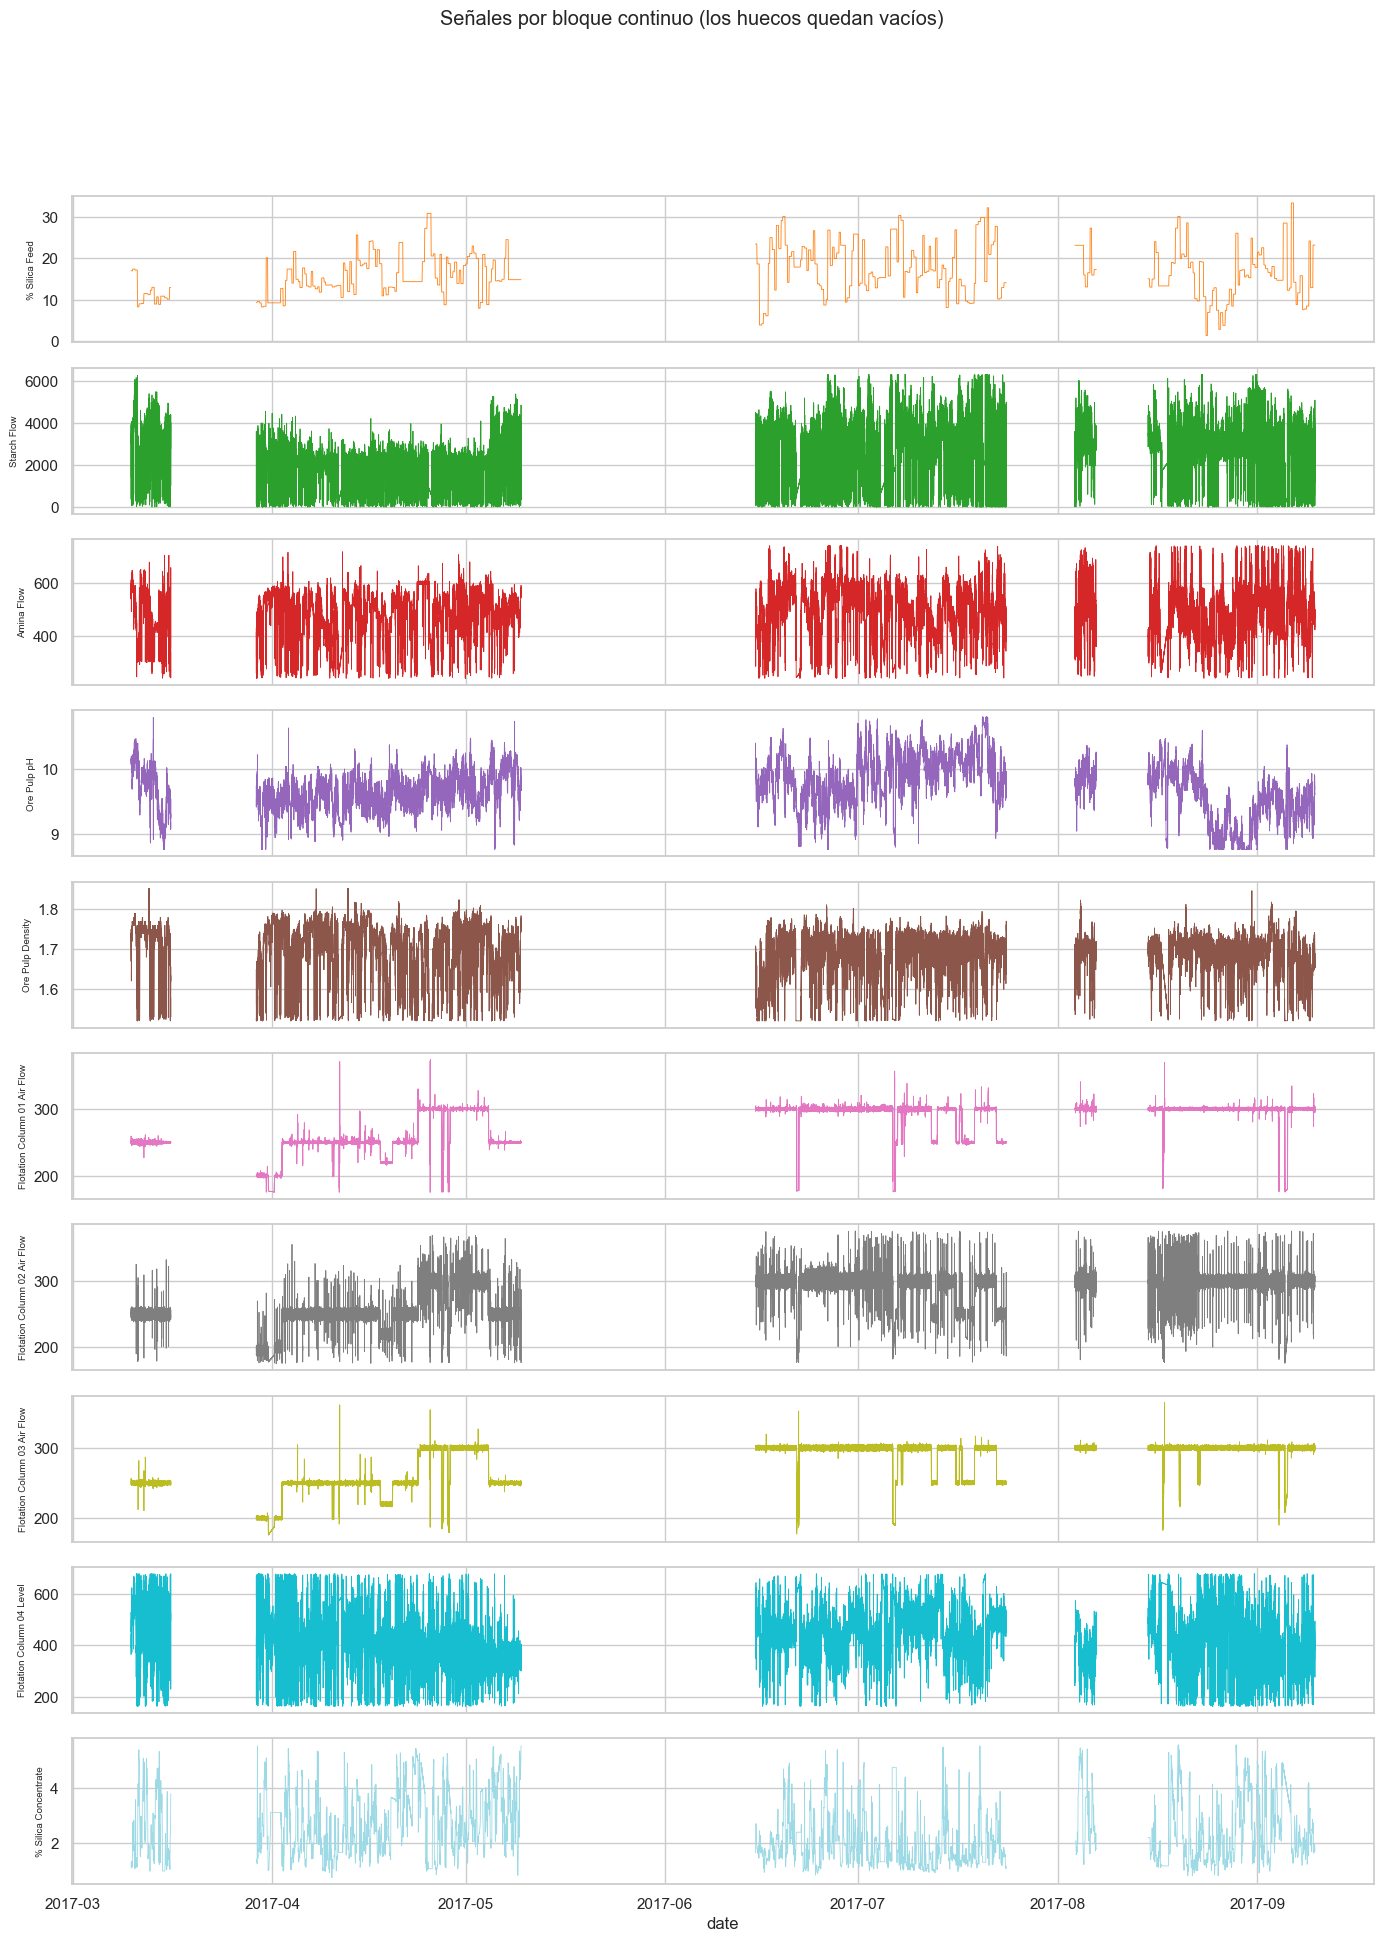

In [44]:
n = len(bloques[0].columns)
fig, axes = plt.subplots(n, 1, figsize=(14, 1.8 * n), sharex=True)
colores = plt.cm.tab20(np.linspace(0, 1, n))

for ax, var, c in zip(axes, bloques[0].columns, colores):
    if var == TIMESTAMP_COL:
        ax.axis("off")
        continue
    for b in bloques:
        ax.plot(b[TIMESTAMP_COL], b[var], color=c, linewidth=0.6)
    ax.set_ylabel(var, fontsize=7)

axes[-1].set_xlabel(TIMESTAMP_COL)
plt.suptitle("Señales por bloque continuo (los huecos quedan vacíos)")
plt.tight_layout()
plt.show()

## 7. Feature engineering

Una única definición de `construir_features`, aplicada **por bloque** para que ningún
lag ni ventana cruce un corte temporal.

Para el soft sensor las features derivadas son opcionales — la señal principal es
simultánea. Se dejan parametrizadas porque el notebook de forecasting reutiliza la misma
función.

In [45]:
def construir_features(df, variables, *, incluir_target=False,
                       lags=None, rolling_mean=None, rolling_std=None,
                       diff=False, col_tiempo=TIMESTAMP_COL,
                       target=TARGET):
    """Añade features temporales a un bloque continuo.

    Todas las ventanas usan `.shift(1)` para que la feature en t solo mire a
    información de t-1 hacia atrás. Sin ese shift, la media móvil incluye el
    instante actual y filtra el presente en la predicción.

    Devuelve (df_ampliado, lista_de_features).
    """
    out = df.copy()
    nuevas, nombres = {}, [c for c in variables
                           if c not in (col_tiempo, target)]

    for var in variables:
        if var == col_tiempo:
            continue
        if var == target and not incluir_target:
            continue

        for lag in (lags or []):
            nuevas[f"{var}_lag_{lag}"] = out[var].shift(lag)
            nombres.append(f"{var}_lag_{lag}")

        for w in (rolling_mean or []):
            nuevas[f"{var}_rmean_{w}"] = out[var].shift(1).rolling(w).mean()
            nombres.append(f"{var}_rmean_{w}")

        for w in (rolling_std or []):
            nuevas[f"{var}_rstd_{w}"] = out[var].shift(1).rolling(w).std()
            nombres.append(f"{var}_rstd_{w}")

        if diff:
            nuevas[f"{var}_diff"] = out[var].diff()
            nombres.append(f"{var}_diff")

    if nuevas:
        out = pd.concat([out, pd.DataFrame(nuevas, index=out.index)], axis=1)

    return out, nombres

In [46]:
bloques_feat = []
for b in bloques:
    bf, cols_feat = construir_features(b, b.columns, diff=True, lags=[1, 2, 3])
    bloques_feat.append(bf.dropna().reset_index(drop=True))

dataset = pd.concat(bloques_feat, ignore_index=True)
dataset = dataset.sort_values(TIMESTAMP_COL).reset_index(drop=True)

FEATURES = [c for c in dataset.columns if c not in (TIMESTAMP_COL, TARGET)]

print(f"Dataset: {dataset.shape[0]:,} filas × {len(FEATURES)} features")
dataset.head()

Dataset: 499,838 filas × 45 features


,date,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,Flotation Column 03 Air Flow,Flotation Column 04 Level,% Silica Concentrate,% Silica Feed_lag_1,% Silica Feed_lag_2,% Silica Feed_lag_3,% Silica Feed_diff,Starch Flow_lag_1,Starch Flow_lag_2,Starch Flow_lag_3,Starch Flow_diff,Amina Flow_lag_1,Amina Flow_lag_2,Amina Flow_lag_3,Amina Flow_diff,Ore Pulp pH_lag_1,Ore Pulp pH_lag_2,Ore Pulp pH_lag_3,Ore Pulp pH_diff,Ore Pulp Density_lag_1,Ore Pulp Density_lag_2,Ore Pulp Density_lag_3,Ore Pulp Density_diff,Flotation Column 01 Air Flow_lag_1,Flotation Column 01 Air Flow_lag_2,Flotation Column 01 Air Flow_lag_3,Flotation Column 01 Air Flow_diff,Flotation Column 02 Air Flow_lag_1,Flotation Column 02 Air Flow_lag_2,Flotation Column 02 Air Flow_lag_3,Flotation Column 02 Air Flow_diff,Flotation Column 03 Air Flow_lag_1,Flotation Column 03 Air Flow_lag_2,Flotation Column 03 Air Flow_lag_3,Flotation Column 03 Air Flow_diff,Flotation Column 04 Level_lag_1,Flotation Column 04 Level_lag_2,Flotation Column 04 Level_lag_3,Flotation Column 04 Level_diff
0,2017-03-10 01:00:00,16.98,3180.86,600.464,10.1130,1.73476,250.576,250.620,249.258,415.706,1.31,16.98,16.98,16.98,0.0,3182.03,3185.55,3019.53,-1.17,595.947,586.182,557.434,4.517,10.1135,10.1139,10.0664,-0.0005,1.73545,1.73614,1.74000,-0.00069,250.620,250.488,249.214,-0.044,252.334,250.488,253.235,-1.714,249.390,249.214,250.576,-0.132,405.704,422.888,443.558,10.002
1,2017-03-10 01:00:00,16.98,3043.46,568.054,10.0680,1.74000,249.741,247.874,250.313,449.688,1.31,16.98,16.98,16.98,0.0,3024.41,3172.07,3798.05,19.05,563.965,601.654,563.110,4.089,10.0672,10.1227,10.0812,0.0008,1.74000,1.74668,1.74000,0.00000,249.719,251.071,250.203,0.022,250.532,250.543,248.181,-2.658,250.862,251.960,250.291,-0.549,448.086,410.289,425.780,1.602
2,2017-03-10 01:00:00,16.98,3047.36,568.665,10.0689,1.74000,249.917,254.487,250.049,446.210,1.31,16.98,16.98,16.98,0.0,3043.46,3024.41,3172.07,3.90,568.054,563.965,601.654,0.611,10.0680,10.0672,10.1227,0.0009,1.74000,1.74000,1.74668,0.00000,249.741,249.719,251.071,0.176,247.874,250.532,250.543,6.613,250.313,250.862,251.960,-0.264,449.688,448.086,410.289,-3.478
3,2017-03-10 01:00:00,16.98,3033.69,558.167,10.0697,1.74000,250.203,252.136,249.895,453.670,1.31,16.98,16.98,16.98,0.0,3047.36,3043.46,3024.41,-13.67,568.665,568.054,563.965,-10.498,10.0689,10.0680,10.0672,0.0008,1.74000,1.74000,1.74000,0.00000,249.917,249.741,249.719,0.286,254.487,247.874,250.532,-2.351,250.049,250.313,250.862,-0.154,446.210,449.688,448.086,7.460
4,2017-03-10 01:00:00,16.98,3079.10,564.697,10.0705,1.74000,250.730,248.906,249.521,439.920,1.31,16.98,16.98,16.98,0.0,3033.69,3047.36,3043.46,45.41,558.167,568.665,568.054,6.530,10.0697,10.0689,10.0680,0.0008,1.74000,1.74000,1.74000,0.00000,250.203,249.917,249.741,0.527,252.136,254.487,247.874,-3.230,249.895,250.049,250.313,-0.374,453.670,446.210,449.688,-13.750


## 8. Split cronológico

**El punto crítico.** `train_test_split(shuffle=True)` sobre datos a 20 s coloca vecinos
inmediatos a ambos lados del split. El modelo no predice: interpola entre puntos casi
idénticos que ya vio. Es la diferencia entre examinarse de memoria y examinarse con el
libro abierto.

Aquí el test es el **último 20 % en el tiempo**, que es la única forma de simular el
despliegue real: modelo entrenado con el pasado, evaluado contra un futuro que no vio.

In [47]:
corte = int(len(dataset) * (1 - TEST_FRACTION))

train, test = dataset.iloc[:corte], dataset.iloc[corte:]
X_train, y_train = train[FEATURES], train[TARGET]
X_test,  y_test  = test[FEATURES],  test[TARGET]

print(f"Train: {len(train):>7,} | {train[TIMESTAMP_COL].min()} -> {train[TIMESTAMP_COL].max()}")
print(f"Test : {len(test):>7,} | {test[TIMESTAMP_COL].min()} -> {test[TIMESTAMP_COL].max()}")
print(f"\nMedia target — train: {y_train.mean():.3f} | test: {y_test.mean():.3f}")
print(f"Std   target — train: {y_train.std():.3f} | test: {y_test.std():.3f}")

Train: 399,870 | 2017-03-10 01:00:00 -> 2017-08-17 20:00:00
Test :  99,968 | 2017-08-17 20:00:00 -> 2017-09-09 23:00:00

Media target — train: 2.376 | test: 2.519
Std   target — train: 1.124 | test: 1.213


Compara las dos medias. Si difieren de forma apreciable hay **drift**: el régimen de
operación cambió entre el periodo de train y el de test. Eso no es un bug del split, es
información sobre el proceso — y explicaría un R² bajo mejor que cualquier
hiperparámetro.

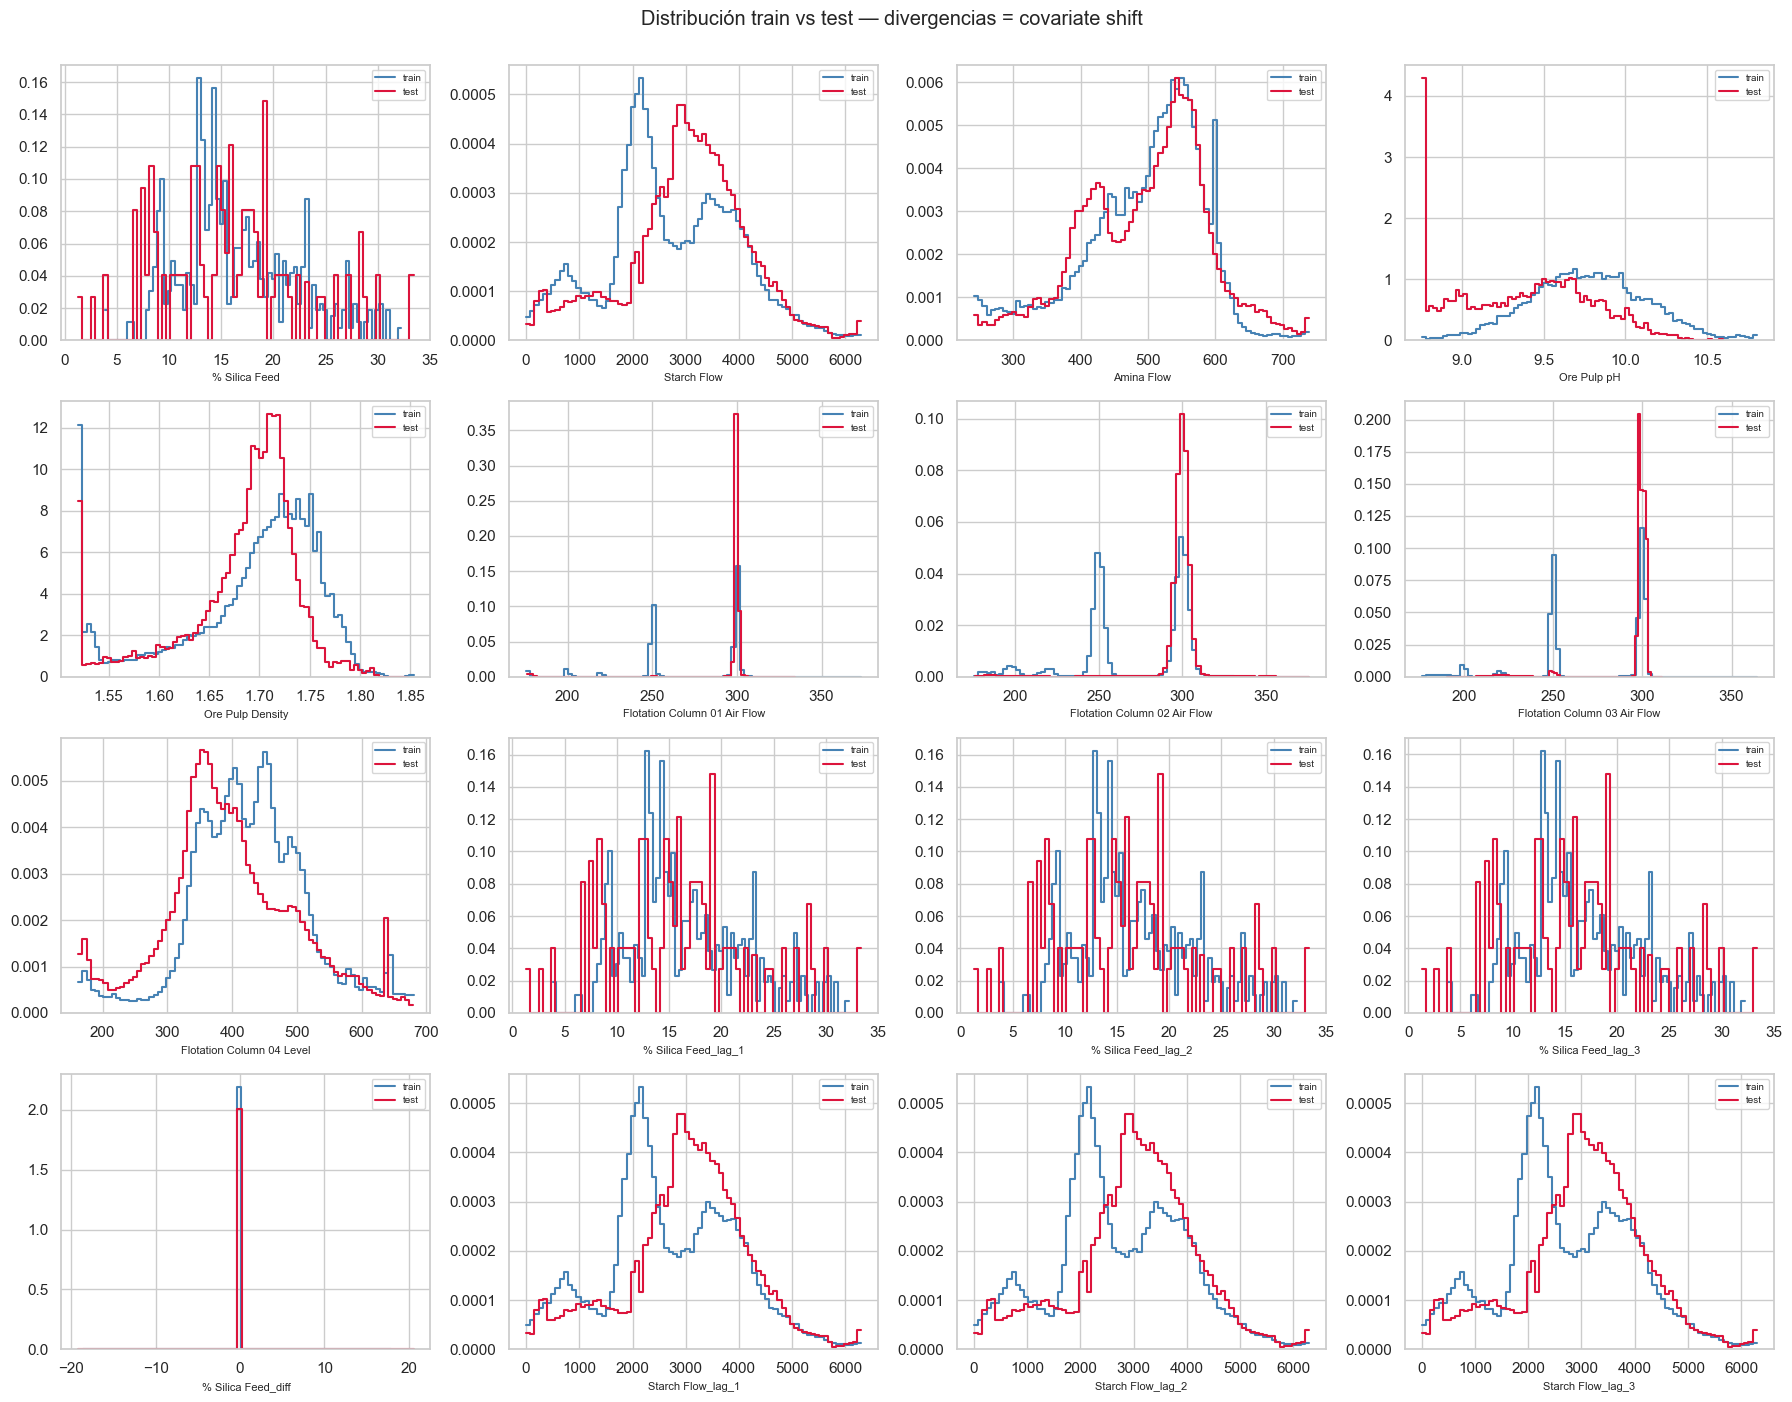

In [48]:
a_dibujar = [f for f in FEATURES if "_diff" not in f or "_lag_" not in f][:16]
fig, axes = plt.subplots(4, 4, figsize=(18, 14))

for ax, f in zip(axes.flatten(), a_dibujar):
    sns.histplot(X_train[f], color="steelblue", bins=80, stat="density",
                 label="train", ax=ax, element="step", fill=False)
    sns.histplot(X_test[f], color="crimson", bins=80, stat="density",
                 label="test", ax=ax, element="step", fill=False)
    ax.set_xlabel(f, fontsize=8)
    ax.set_ylabel("")
    ax.legend(fontsize=7)

for ax in axes.flatten()[len(a_dibujar):]:
    ax.axis("off")

plt.suptitle("Distribución train vs test — divergencias = covariate shift", y=1.00)
plt.tight_layout()
plt.show()

## 9. Baselines

Sin baseline, un R² no significa nada. Dos referencias:

- **Media** — predice siempre el promedio del train. El suelo absoluto.
- **Persistencia** — predice el último valor observado. En procesos con inercia suele ser
  sorprendentemente difícil de batir, y es el rival honesto.

Si XGBoost no supera claramente la persistencia, el modelo no aporta nada sobre "mira el
valor anterior".

In [49]:
def reporte(y_true, y_pred, nombre):
    return {
        "modelo": nombre,
        "RMSE": root_mean_squared_error(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }


resultados = []

media = DummyRegressor(strategy="mean").fit(X_train, y_train)
resultados.append(reporte(y_test, media.predict(X_test), "Baseline: media"))

persistencia = test[TARGET].shift(1).bfill()
resultados.append(reporte(y_test, persistencia, "Baseline: persistencia"))

pd.DataFrame(resultados).round(4)

,modelo,RMSE,MAE,R2
0,Baseline: media,1.2215,1.0132,-0.0139
1,Baseline: persistencia,0.0584,0.0035,0.9977


## 10. Modelo

In [50]:
modelo = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.1,
    max_depth=6,
    # subsample=0.8,
    # colsample_bytree=0.8,
    early_stopping_rounds=50,   # necesario para que best_iteration signifique algo
    # eval_metric="rmse",
    random_state=RANDOM_STATE,
    # n_jobs=-1,
)

modelo.fit(X_train, y_train,
           eval_set=[(X_train, y_train), (X_test, y_test)],
           verbose=False)

print(f"Mejor iteración: {modelo.best_iteration} de {modelo.n_estimators}")

Mejor iteración: 20 de 1000


**Aviso metodológico:** el early stopping usa `X_test` como conjunto de validación, así
que el número de árboles se ha elegido mirando el test. Las métricas de abajo están
ligeramente optimistas. Para un número limpio, separa un tercer bloque cronológico de
validación y deja el test intacto hasta el final.

In [51]:
pred_train = modelo.predict(X_train)
pred_test  = modelo.predict(X_test)

resultados.append(reporte(y_train, pred_train, "XGBoost (train)"))
resultados.append(reporte(y_test,  pred_test,  "XGBoost (test)"))

tabla = pd.DataFrame(resultados).round(4)
tabla

,modelo,RMSE,MAE,R2
0,Baseline: media,1.2215,1.0132,-0.0139
1,Baseline: persistencia,0.0584,0.0035,0.9977
2,XGBoost (train),0.8392,0.6615,0.4421
3,XGBoost (test),1.1999,0.9414,0.0216


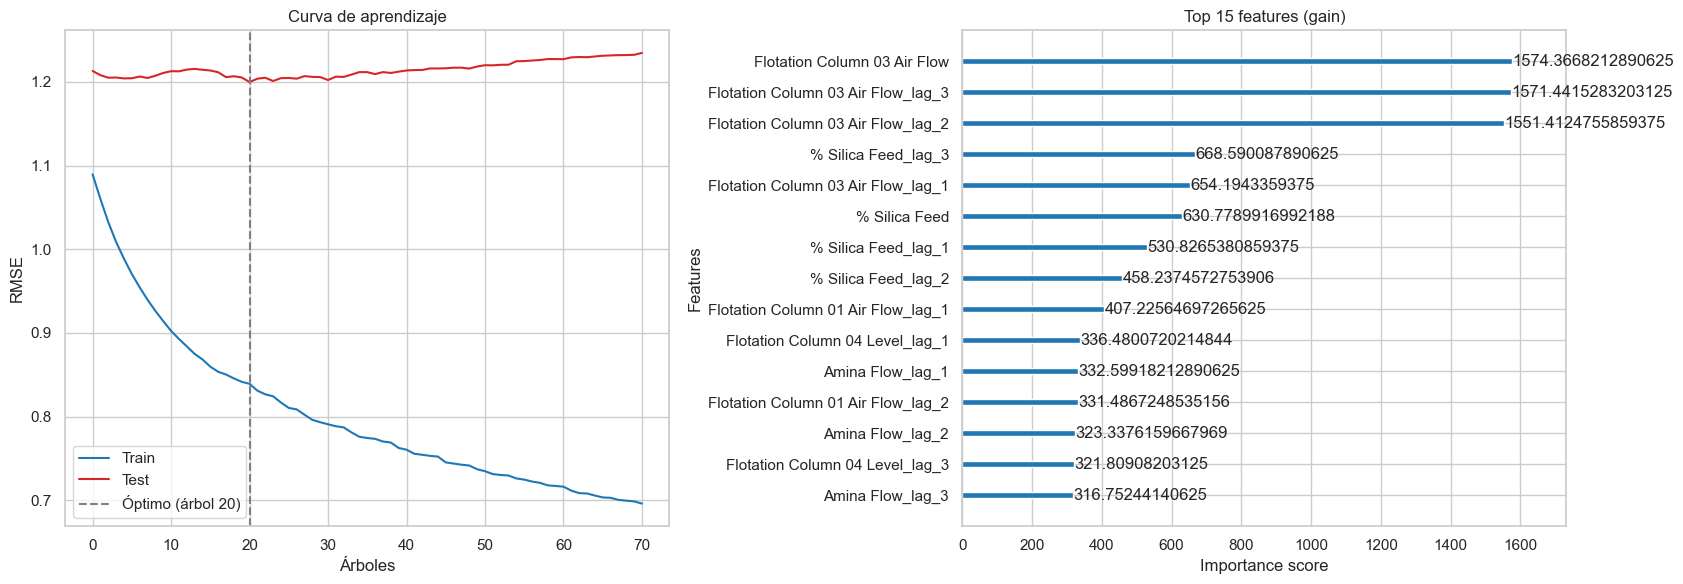

In [52]:
hist = modelo.evals_result()

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

axes[0].plot(hist["validation_0"]["rmse"], label="Train", color="#1f77b4")
axes[0].plot(hist["validation_1"]["rmse"], label="Test", color="#d62728")
axes[0].axvline(modelo.best_iteration, color="gray", linestyle="--",
                label=f"Óptimo (árbol {modelo.best_iteration})")
axes[0].set_title("Curva de aprendizaje")
axes[0].set_xlabel("Árboles")
axes[0].set_ylabel("RMSE")
axes[0].legend()

xgb.plot_importance(modelo, importance_type="gain", max_num_features=15,
                    ax=axes[1], color="#1f77b4")
axes[1].set_title("Top 15 features (gain)")

plt.tight_layout()
plt.show()

Una separación creciente entre las dos curvas es overfitting. Pero con split cronológico
hay una segunda lectura: si la curva de test sube desde el principio, el problema puede
ser drift, no capacidad — el modelo aprende un régimen que ya no existe en el test.

## 11. Diagnóstico

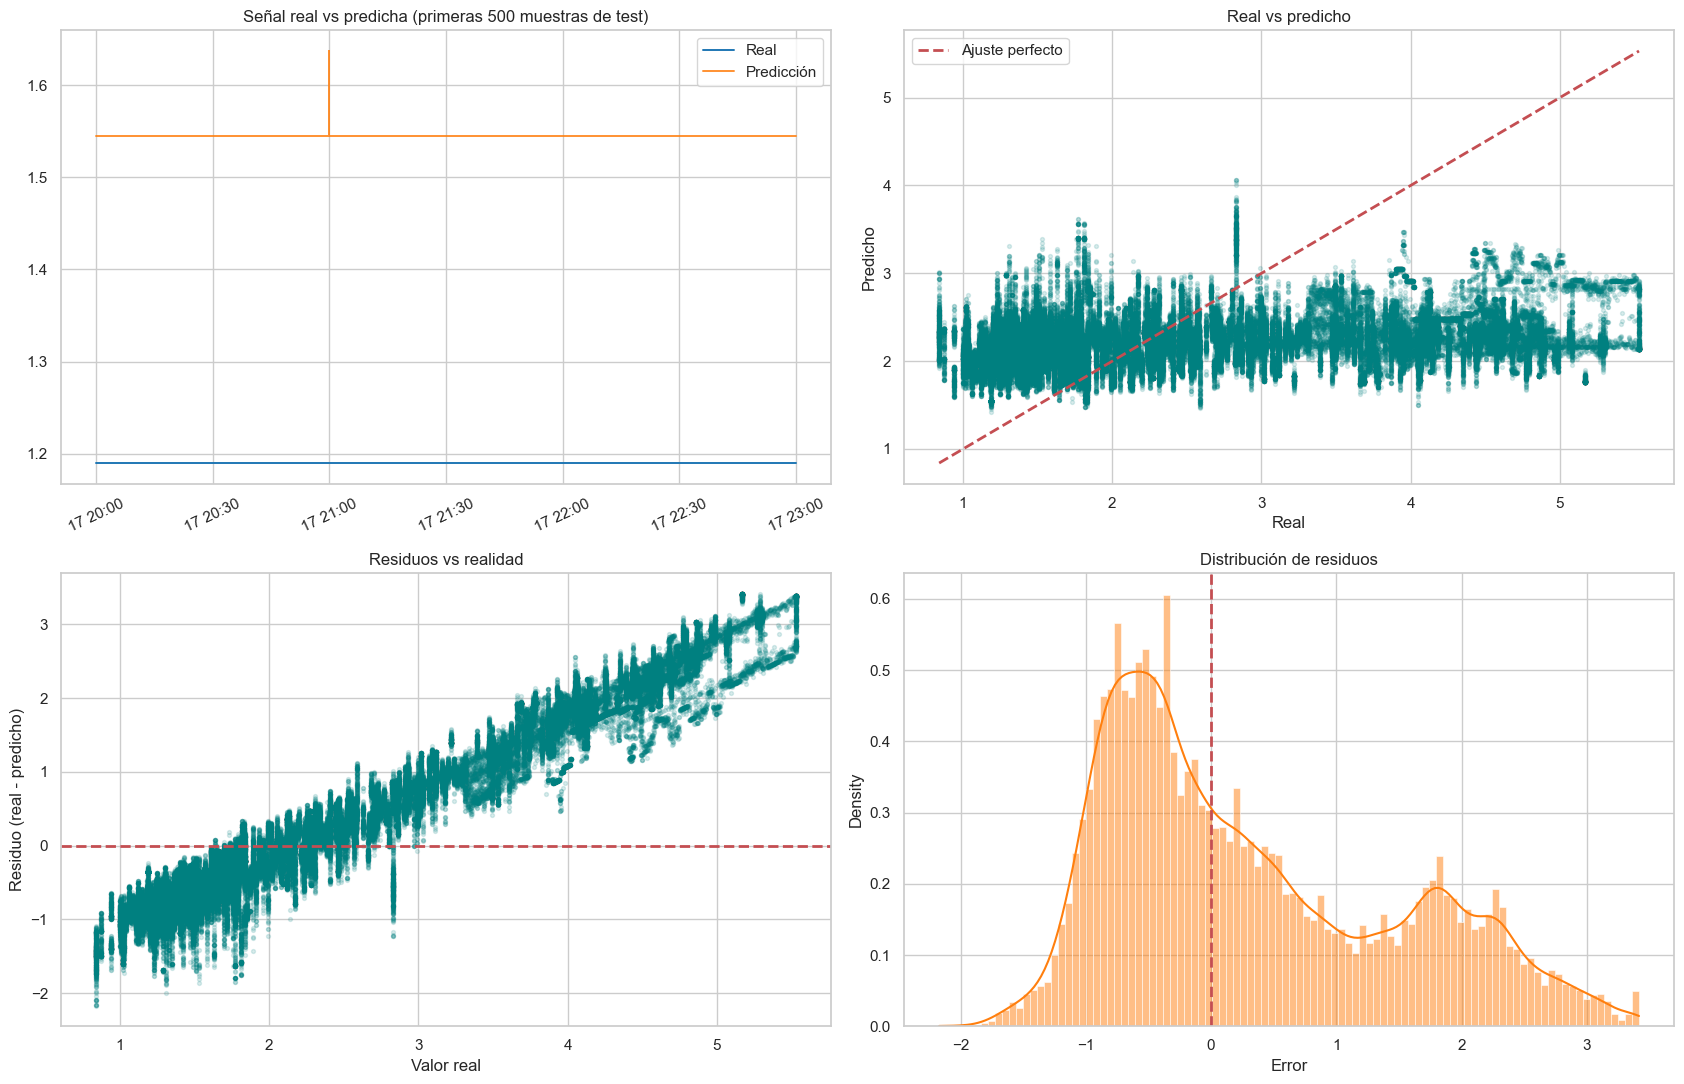

Sesgo (media de residuos): +0.3123
Desviación de residuos:    1.1586


In [53]:
residuos = y_test.to_numpy() - pred_test
N = 500

fig, axes = plt.subplots(2, 2, figsize=(17, 11))

axes[0, 0].plot(test[TIMESTAMP_COL].iloc[:N], y_test.iloc[:N],
                label="Real", color="#1f77b4", linewidth=1.4)
axes[0, 0].plot(test[TIMESTAMP_COL].iloc[:N], pred_test[:N],
                label="Predicción", color="#ff7f0e", alpha=0.85, linewidth=1.4)
axes[0, 0].set_title(f"Señal real vs predicha (primeras {N} muestras de test)")
axes[0, 0].tick_params(axis="x", rotation=25)
axes[0, 0].legend()

axes[0, 1].scatter(y_test, pred_test, alpha=0.15, color="teal", s=8)
lims = [min(y_test.min(), pred_test.min()), max(y_test.max(), pred_test.max())]
axes[0, 1].plot(lims, lims, "r--", linewidth=2, label="Ajuste perfecto")
axes[0, 1].set_xlabel("Real")
axes[0, 1].set_ylabel("Predicho")
axes[0, 1].set_title("Real vs predicho")
axes[0, 1].legend()

axes[1, 0].scatter(y_test, residuos, alpha=0.15, color="teal", s=8)
axes[1, 0].axhline(0, color="r", linestyle="--", linewidth=2)
axes[1, 0].set_xlabel("Valor real")
axes[1, 0].set_ylabel("Residuo (real - predicho)")
axes[1, 0].set_title("Residuos vs realidad")

sns.histplot(residuos, kde=True, bins=100, ax=axes[1, 1],
             color="#ff7f0e", stat="density")
axes[1, 1].axvline(0, color="r", linestyle="--", linewidth=2)
axes[1, 1].set_title("Distribución de residuos")
axes[1, 1].set_xlabel("Error")

plt.tight_layout()
plt.show()

print(f"Sesgo (media de residuos): {residuos.mean():+.4f}")
print(f"Desviación de residuos:    {residuos.std():.4f}")

**Cómo leer el panel inferior izquierdo.** Una pendiente negativa clara significa que el
modelo tira hacia la media: sobreestima los valores bajos y subestima los altos. Es el
comportamiento por defecto de cualquier regresor cuando las features explican poco —
apuesta por el promedio porque es lo que minimiza el error cuadrático.

Operativamente eso importa: si los valores altos de sílice son los que disparan una
acción correctiva, un modelo que los subestima sistemáticamente falla justo cuando hace
falta.

## 12. Conclusiones

Rellena esto con los números que salgan, no con los que esperabas.

- [ ] ¿Bate XGBoost a la persistencia? Si no, el modelo no aporta nada.
- [ ] ¿Cuánto cae el R² respecto al split aleatorio original? Esa caída es la medida
      exacta de la fuga que había.
- [ ] ¿Es el sesgo hacia la media aceptable para el uso operativo previsto?
- [ ] ¿Hay drift entre train y test que explique parte del error?